# Compute ab resilience and compare with Vocs Escape

In [2]:
import os
import sys
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# from utils_analysis_mf import *
from tqdm import tqdm

main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils

from global_variables import *
from utils_evaluate_seq import *


e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(
e:\ESCAPE_PATHS\covid\../PGM/utilities\RBM_utils.py:318: SyntaxWarning: invali

Loaded 29 KD vectors


# Cao analysis

In [3]:
df_labels=pd.read_csv('ab_resilience/exp_data/results/antibody_IC50s.csv')
df_labels

,antibody,virus,IC50
0,BD30-604,D614G,0.0110
1,BD45-21,D614G,0.0532
2,BD45-70,D614G,0.0015
3,BD45-105,D614G,0.5740
4,BD45-145,D614G,0.0054
...,...,...,...
33375,BD55-6726,XBB,10.0000
33376,BD55-6727,XBB,10.0000
33377,BD55-6728,XBB,10.0000
33378,BD55-6729,XBB,10.0000


# Exp data

In [5]:
escape_vectors_directory = "escape_vectors"
os.chdir('ab_resilience')
ESCAPE_VECTORS_CAO = load_kd_vectors(escape_vectors_directory)
os.chdir('../')

Loaded 4130 KD vectors


# Paths proba and average escape

In [7]:
folder = '../mean_field_theory/results_scripts/covid_D_20/mean_f_free_ab_beta_ab_1._D_20.npy'
proba=np.load(folder)#shape: Q,T,L
#make it to T,L,Q
# Assuming proba has shape (Q, T, L)
proba = proba.transpose(1, 2, 0)  # New shape: (T, L, Q)
#make it to (T,L*Q)
T, L, Q = proba.shape
proba_flat = proba.reshape(T, L * Q)
proba_flat.shape
proba_flat

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.27004962e-60, 8.62340804e-60, 5.93454605e-60, ...,
        3.08350340e-60, 5.86772558e-60, 1.66198077e-59],
       [1.82623160e-55, 3.38107424e-55, 2.46444733e-55, ...,
        1.35288618e-55, 2.43810098e-55, 6.11833477e-55],
       ...,
       [1.33360270e-10, 1.75263170e-10, 1.61161202e-10, ...,
        1.15943094e-10, 1.85910984e-10, 3.48596167e-10],
       [6.36470339e-09, 9.75314023e-09, 8.56831183e-09, ...,
        5.31990865e-09, 1.10475501e-08, 2.97714857e-08],
       [4.24358415e-06, 5.51160131e-06, 5.09669871e-06, ...,
        3.69894652e-06, 5.83249445e-06, 1.03961914e-05]])

In [8]:
import pandas as pd
import numpy as np

# Confirm shape
assert proba_flat.shape[1] == 3560, f"Expected shape (T, 3560), got {proba_flat.shape}"

# Compute dot products
dot_products = {}
for ab_name, escape_vec in ESCAPE_VECTORS_CAO.items():
    escape_vec = np.ravel(escape_vec)             # (3560,)
    dot = proba_flat @ escape_vec                      # (T,)
    dot_products[ab_name] = dot

# Create DataFrame
df_dot = pd.DataFrame.from_dict(dot_products, orient='index')
df_dot.columns = [f"step_{t}" for t in range(proba.shape[0])]
df_dot.index.name = "antibody"
df_dot.reset_index(inplace=True)

df_dot

,antibody,step_0,step_1,step_2,step_3,step_4,step_5,step_6,step_7,step_8,...,step_11,step_12,step_13,step_14,step_15,step_16,step_17,step_18,step_19,step_20
0,1-57,-0.178089,-0.178216,-0.180026,-0.184712,-0.193047,-0.205657,-0.222193,-0.241038,-0.259560,...,-0.291777,-0.294734,-0.295970,-0.296437,-0.296626,-0.296806,-0.297261,-0.298524,-0.301534,-0.307177
1,2-15,-0.178089,-0.178092,-0.178115,-0.178158,-0.178223,-0.178320,-0.178458,-0.178652,-0.178918,...,-0.180205,-0.180759,-0.181355,-0.181994,-0.182689,-0.183448,-0.184253,-0.185060,-0.185938,-0.187446
2,7D6,-0.178089,-0.178089,-0.178089,-0.178089,-0.178089,-0.178089,-0.178089,-0.178089,-0.178090,...,-0.178133,-0.178244,-0.178567,-0.179428,-0.181530,-0.186205,-0.195316,-0.209836,-0.226846,-0.238697
3,ADG-2,-0.178089,-0.178089,-0.178089,-0.178089,-0.178089,-0.178089,-0.178089,-0.178089,-0.178089,...,-0.178089,-0.178090,-0.178093,-0.178105,-0.178152,-0.178322,-0.178861,-0.180353,-0.184000,-0.191279
4,B38,-0.178089,-0.178118,-0.178538,-0.179801,-0.182592,-0.188199,-0.198527,-0.216151,-0.243904,...,-0.392208,-0.451417,-0.507650,-0.558505,-0.603013,-0.640637,-0.670733,-0.692808,-0.706910,-0.714152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4125,XGv-416,-0.178089,-0.178089,-0.178089,-0.178092,-0.178100,-0.178130,-0.178215,-0.178433,-0.178917,...,-0.183332,-0.185661,-0.188060,-0.190374,-0.192639,-0.195215,-0.198950,-0.204932,-0.212942,-0.219479
4126,XGv-418,-0.178089,-0.178089,-0.178089,-0.178090,-0.178091,-0.178093,-0.178095,-0.178098,-0.178103,...,-0.178143,-0.178181,-0.178244,-0.178345,-0.178495,-0.178702,-0.178963,-0.179283,-0.179873,-0.181780
4127,XGv-420,-0.178089,-0.261164,-0.652547,-1.021073,-1.279229,-1.444674,-1.541790,-1.593754,-1.618839,...,-1.634664,-1.634994,-1.635073,-1.635090,-1.635093,-1.635094,-1.635094,-1.635092,-1.635078,-1.635389
4128,XGv-421,-0.178089,-0.234002,-0.497421,-0.745455,-0.919205,-1.030557,-1.095920,-1.130895,-1.147778,...,-1.158429,-1.158652,-1.158709,-1.158738,-1.158818,-1.159127,-1.160205,-1.163343,-1.170204,-1.178976


# labels =  voc binding

In [9]:
df_labels=pd.read_csv('ab_resilience/exp_data/results/antibody_IC50s.csv')
df_labels['virus'].unique()
df_source=pd.read_csv('ab_resilience/exp_data/results/antibody_sources.csv')
ab_wt=df_source[df_source['source']=='WT convalescents']['antibody'].unique()

df_labels = df_labels[df_labels['antibody'].isin(ab_wt)]
df_labels

,antibody,virus,IC50
0,BD30-604,D614G,0.0110
1,BD45-21,D614G,0.0532
2,BD45-70,D614G,0.0015
3,BD45-105,D614G,0.5740
4,BD45-145,D614G,0.0054
...,...,...,...
31030,BD55-979,XBB,10.0000
31031,BD55-987,XBB,10.0000
31032,BD55-988,XBB,10.0000
31033,BD55-998,XBB,10.0000


In [10]:
# Merge step columns into df_labels using the 'antibody' column
df_full = df_labels.merge(df_dot, on='antibody', how='right')
len(df_full)

6828

In [11]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

step_cols = [col for col in df_full.columns if col.startswith('step_')]
result_rows = []

# Binary label: IC50 > 5
df_full = df_full.copy()
df_full['label'] = df_full['IC50'] > 5

# Group by virus
for virus, group in df_full.groupby('virus'):
    if group['label'].nunique() < 2:
        continue  # Skip if only one class present (AUC not defined)

    best_auc = -1
    best_step = None

    for step in step_cols:
        if group[step].isnull().any():
            continue  # skip if missing data

        try:
            auc = roc_auc_score(group['label'], -group[step])
            if auc > best_auc:
                best_auc = auc
                best_step = step
        except ValueError:
            continue  # skip step if only one class in label

    if best_step is not None:
        result_rows.append({
            'virus': virus,
            'n_ab': len(group),
            'best_step': best_step,
            'auc': best_auc
        })

# Create summary dataframe
result_df = pd.DataFrame(result_rows)
result_df

,virus,n_ab,best_step,auc
0,BA.1,438,step_20,0.617797
1,BA.1.1,9,step_3,1.000000
2,BA.2,438,step_20,0.591416
3,BA.2.12.1,12,step_0,0.909091
4,BA.2.13,7,step_14,1.000000
5,BA.2.75,438,step_20,0.602240
6,BA.3,12,step_3,1.000000
7,BA.5,438,step_20,0.583157
8,BQ.1.1,436,step_20,0.677178
9,D614G,438,step_20,0.696526


In [12]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

step_cols = [col for col in df_full.columns if col.startswith('step_')]
df_full = df_full.copy()
df_full['label'] = df_full['IC50'] > 5

# Ensure requested steps exist
requested_steps = [0, 1, 2, 15, 19]
step_names = [f'step_{i}' for i in requested_steps if f'step_{i}' in step_cols]

result_rows = []

# Group by virus
for virus, group in df_full.groupby('virus'):
    if group['label'].nunique() < 2:
        continue  # Need both classes

    aucs = {}
    for step in step_names:
        col_values = group[step]
        if col_values.isnull().any():
            aucs[step] = np.nan
        else:
            try:
                aucs[step] = roc_auc_score(group['label'], -col_values)
            except ValueError:
                aucs[step] = np.nan

    result_rows.append({'virus': virus, 'n_ab': len(group), **aucs})

# Final result
result_df = pd.DataFrame(result_rows)
result_df = result_df[['virus', 'n_ab'] + step_names]
result_df

,virus,n_ab,step_0,step_1,step_2,step_15,step_19
0,BA.1,438,0.485238,0.563390,0.568977,0.592709,0.609882
1,BA.1.1,9,0.638889,0.833333,0.833333,1.000000,1.000000
2,BA.2,438,0.477022,0.515742,0.522569,0.550449,0.582458
3,BA.2.12.1,12,0.909091,0.909091,0.909091,0.909091,0.909091
4,BA.2.13,7,0.833333,0.833333,0.833333,1.000000,1.000000
5,BA.2.75,438,0.487321,0.535714,0.542711,0.564675,0.593766
6,BA.3,12,0.648148,0.814815,0.888889,0.888889,0.888889
7,BA.5,438,0.469489,0.518386,0.524912,0.548104,0.576411
8,BQ.1.1,436,0.486229,0.607640,0.617129,0.635328,0.670268
9,D614G,438,0.491429,0.542500,0.545795,0.632013,0.682403


In [13]:
result_df.virus.unique()

array(['BA.1', 'BA.1.1', 'BA.2', 'BA.2.12.1', 'BA.2.13', 'BA.2.75',
       'BA.3', 'BA.5', 'BQ.1.1', 'D614G', 'SARS', 'XBB', 'XBB.1.5',
       'XBB.1.5.10'], dtype=object)

C:\Users\maria\AppData\Local\Temp\ipykernel_31044\365784557.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=auc_df, x='auc', y='label_str', palette='viridis')


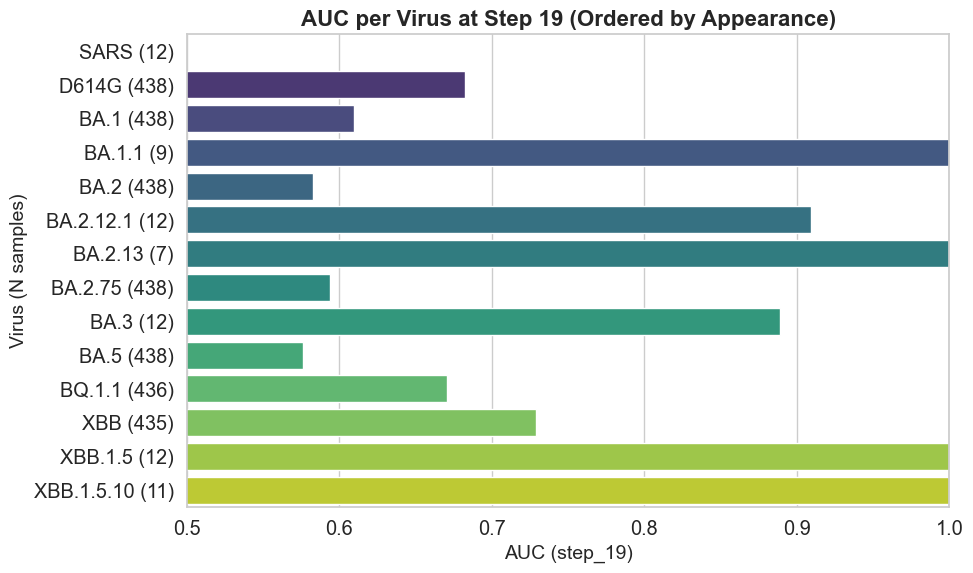

In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Filter and prepare data
df_full = df_full.copy()
df_full['label'] = df_full['IC50'] > 5
step_name = 'step_19'

# Compute AUC per virus
result_rows = []
for virus, group in df_full.groupby('virus'):
    if group['label'].nunique() < 2:
        continue
    try:
        auc = roc_auc_score(group['label'], -group[step_name])
    except ValueError:
        auc = np.nan
    result_rows.append({
        'virus': virus,
        'n_ab': len(group),
        'auc': auc,
        'label_str': f"{virus} ({len(group)})"
    })

# Create DataFrame
auc_df = pd.DataFrame(result_rows).dropna(subset=['auc'])

# Define virus appearance order
appearance_order = [
    'SARS', 'D614G', 'BA.1', 'BA.1.1', 'BA.2', 'BA.2.12.1', 'BA.2.13',
    'BA.2.75', 'BA.3', 'BA.5', 'BQ.1.1', 'XBB', 'XBB.1.5', 'XBB.1.5.10'
]

# Apply order and use virus label with count
appearance_order_filtered = [v for v in appearance_order if v in auc_df['virus'].values]
virus_to_label = dict(zip(auc_df['virus'], auc_df['label_str']))
ordered_labels = [virus_to_label[v] for v in appearance_order_filtered]

auc_df['label_str'] = pd.Categorical(auc_df['label_str'], categories=ordered_labels, ordered=True)
auc_df = auc_df.sort_values('label_str')

# Plotting
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid", font_scale=1.3)

ax = sns.barplot(data=auc_df, x='auc', y='label_str', palette='viridis')

# Axis formatting
ax.set_xlabel('AUC (step_19)', fontsize=14)
ax.set_ylabel('Virus (N samples)', fontsize=14)
ax.set_title('AUC per Virus at Step 19 (Ordered by Appearance)', fontsize=16, weight='bold')
plt.xlim(0.5, 1.0)
plt.tight_layout()

plt.show()


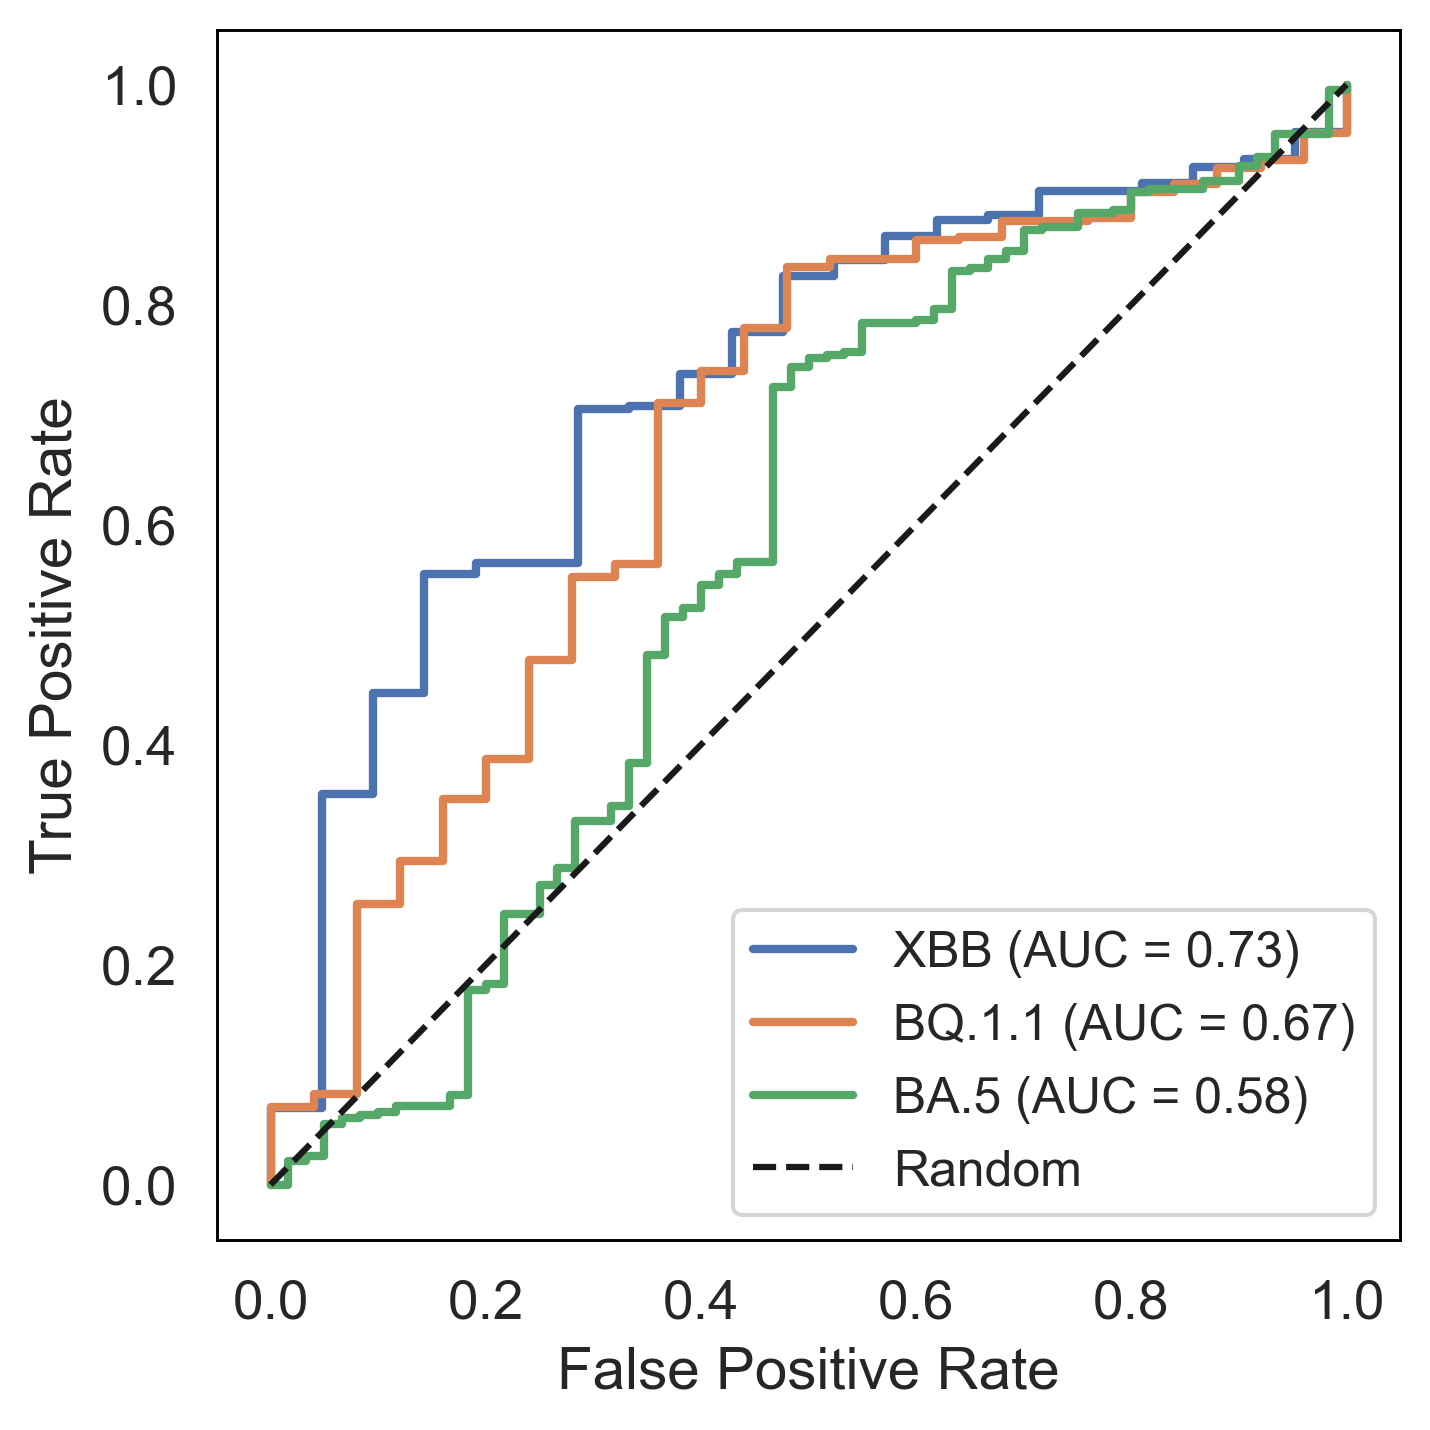

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import numpy as np

# --- Setup ---
variants = {
    'XBB': ['XBB'],
    'BQ.1.1': ['BQ.1.1'],
    'BA.5': ['BA.5']
}

plt.figure(figsize=(5, 5), dpi=300)
sns.set(style="whitegrid", font_scale=1.2)

# --- Plot ROC for each variant group ---
for label, variant_list in variants.items():
    subset = df_full[df_full['virus'].isin(variant_list)].copy()
    subset['label'] = subset['IC50'] > 5
    y_true = subset['label']
    y_score = -subset['step_19']  # assuming lower score = stronger

    # Skip if not enough data
    if y_true.nunique() < 2:
        continue

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.2f})", linewidth=2)

# Plot y = x reference
plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1.5)
plt.grid(False)
# Add black spines
for spine in plt.gca().spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.7)

# Axis labels and title
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
# plt.title('AUC predicted Ab escape vs experiment (Cao et al.)', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()


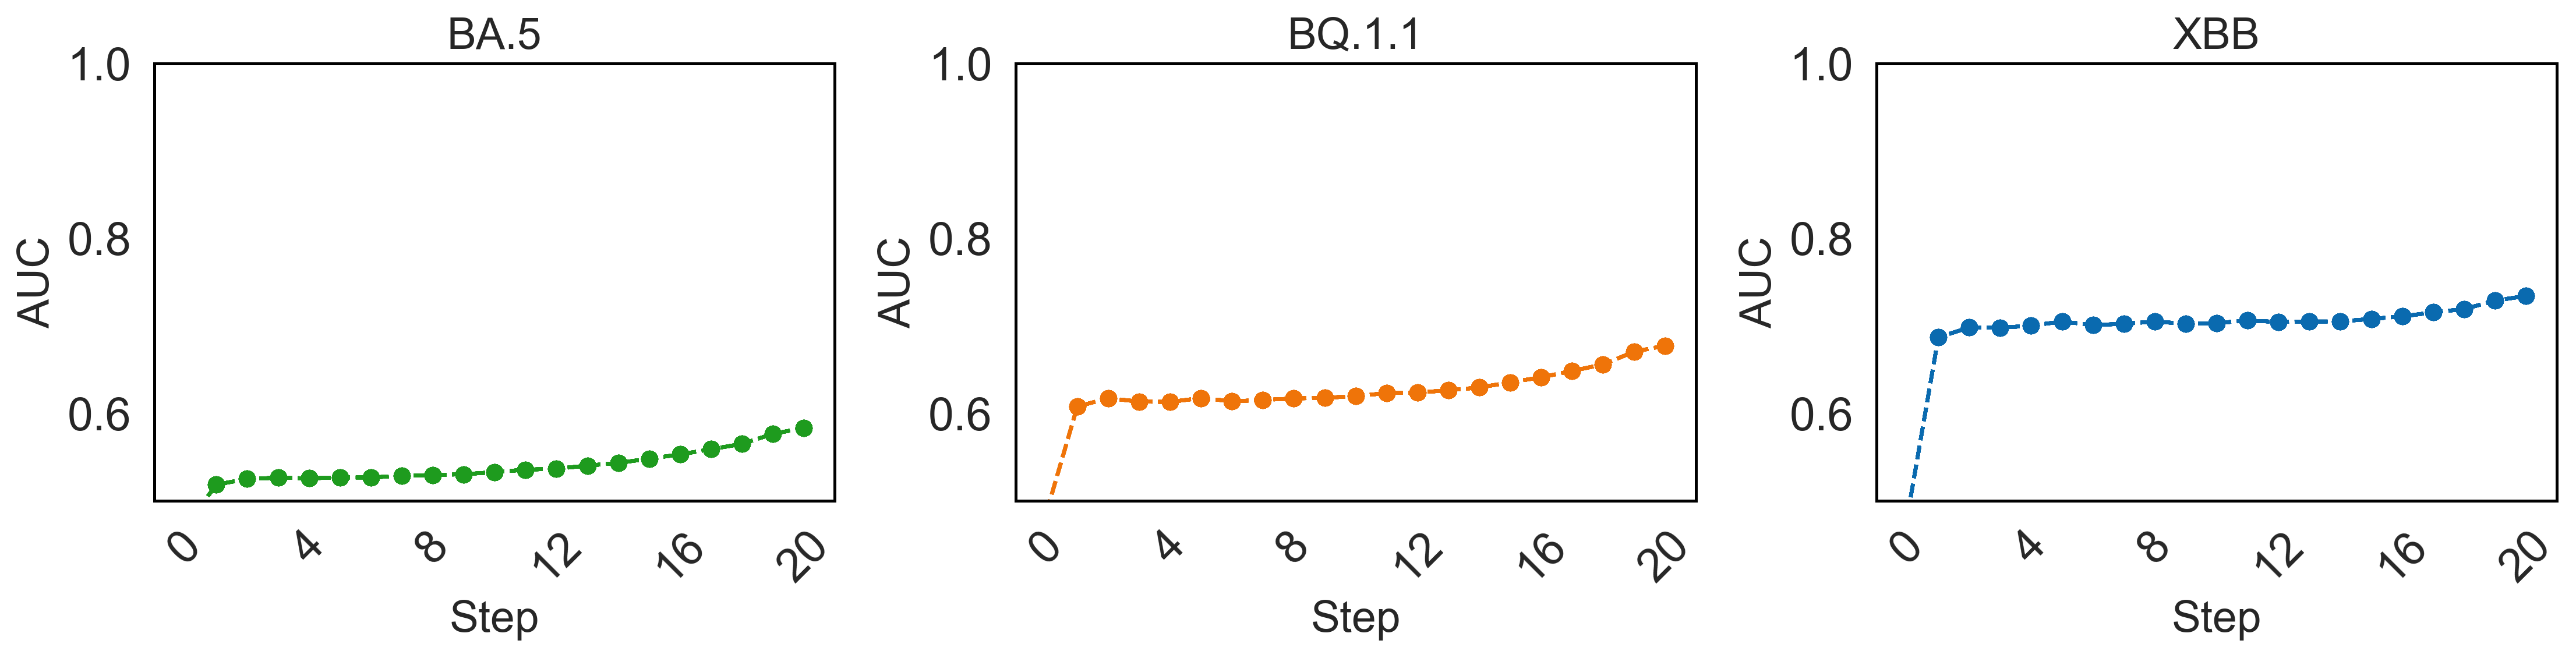

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import seaborn as sns
import numpy as np
import matplotlib as mpl

# --- Variant groups ---
variants = {
    'BA.5': ['BA.5'],
    'BQ.1.1': ['BQ.1.1'],
    'XBB': ['XBB'],
}

# --- Define steps to test ---
step_cols = [col for col in df_full.columns if col.startswith('step_')]
step_nums = [int(col.split('_')[1]) for col in step_cols]
sorted_steps = [f"step_{n}" for n in sorted(step_nums)]

# --- Compute AUCs ---
variant_auc_data = {}

for variant_name, virus_list in variants.items():
    subset = df_full[df_full['virus'].isin(virus_list)].copy()
    subset['label'] = subset['IC50'] > 5

    aucs = []
    for step in sorted_steps:
        y_true = subset['label']
        y_score = -subset[step]  # assuming lower score = stronger
        if y_true.nunique() < 2:
            auc = np.nan
        else:
            try:
                auc = roc_auc_score(y_true, y_score)
            except ValueError:
                auc = np.nan
        aucs.append(auc)
    
    variant_auc_data[variant_name] = aucs

# --- Plotting ---
num_variants = len(variants)
plt.figure(figsize=(5 * num_variants, 4), dpi=300)
sns.set(style="whitegrid", font_scale=1.2)

# Define fixed colors for the three variants:
variant_colors = {
    'BA.5': "#1e9b1e",
    'BQ.1.1': "#ef7409",
    'XBB': "#0a6aaf",
}

for i, (variant_name, aucs) in enumerate(variant_auc_data.items()):
    ax = plt.subplot(1, num_variants, i + 1)
    for j, auc in enumerate(aucs):
        if not np.isnan(auc):
            ax.plot(range(len(aucs)), aucs, 'o--', color=variant_colors[variant_name], markersize=6, linewidth=1.5)    
    ax.set_title(variant_name, fontsize=18)
    ax.set_xlabel('Step', fontsize=18)
    ax.set_ylabel('AUC', fontsize=18)
    ax.set_xticks(range(0, len(sorted_steps), 4))
    ax.set_xticklabels([sorted_steps[i].split('_')[1] for i in range(0, len(sorted_steps), 4)], rotation=45)
    ax.tick_params(axis='both', labelsize=19)

    ax.set_ylim(0.5, 1.0)

    # Add black spines
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
    ax.grid(False)

# Final layout
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

step_cols = [col for col in df_full.columns if col.startswith('step_')]
df_full = df_full.copy()
df_full['label'] = df_full['IC50'] > 5

requested_steps = [0, 1, 2, 15, 19]
step_names = [f'step_{i}' for i in requested_steps if f'step_{i}' in step_cols]

result_rows = []

for virus, group in df_full.groupby('virus'):
    if group['label'].nunique() < 2:
        continue  # Need both classes

    spearman_dict = {}
    for step in step_names:
        values = -group[step]
        labels = group['label']

        if values.isnull().any():
            spearman_dict[step] = np.nan
        else:
            try:
                corr, pval = spearmanr(values, labels)
                spearman_dict[step] = f"{corr:.2f} ({pval:.2g})"
            except Exception:
                spearman_dict[step] = np.nan

    result_rows.append({'virus': virus, 'n_ab': len(group), **spearman_dict})

result_df = pd.DataFrame(result_rows)
result_df = result_df[['virus', 'n_ab'] + step_names]
result_df

,virus,n_ab,step_0,step_1,step_2,step_15,step_19
0,BA.1,438,-0.11 (0.02),0.10 (0.044),0.10 (0.029),0.14 (0.0033),0.17 (0.00048)
1,BA.1.1,9,0.24 (0.54),0.55 (0.13),0.55 (0.13),0.82 (0.0066),0.82 (0.0066)
2,BA.2,438,-0.17 (0.00044),0.02 (0.63),0.03 (0.49),0.07 (0.12),0.12 (0.011)
3,BA.2.12.1,12,0.42 (0.17),0.39 (0.21),0.39 (0.21),0.39 (0.21),0.39 (0.21)
4,BA.2.13,7,0.41 (0.36),0.41 (0.36),0.41 (0.36),0.61 (0.14),0.61 (0.14)
5,BA.2.75,438,-0.09 (0.068),0.05 (0.3),0.06 (0.21),0.09 (0.06),0.13 (0.0064)
6,BA.3,12,0.24 (0.46),0.47 (0.12),0.59 (0.046),0.59 (0.046),0.59 (0.046)
7,BA.5,438,-0.18 (0.00015),0.02 (0.65),0.03 (0.53),0.06 (0.23),0.09 (0.057)
8,BQ.1.1,436,-0.05 (0.25),0.09 (0.069),0.09 (0.048),0.11 (0.023),0.14 (0.0041)
9,D614G,438,-0.06 (0.22),0.06 (0.22),0.06 (0.18),0.18 (0.00011),0.25 (7.8e-08)
